# Chapter 7 - RQ4 Token-Space Perturbations



## 1. Data Layout

The raw H2 decoder-locality exports and the precomputed analysis bundles are consolidated on the server under:

- `/exp/data/h2_decoder_locality/raw/`
- `/exp/data/h2_decoder_locality/analysis_cache/`
- `/exp/data/h2_decoder_locality/relations/`

On the server, this corresponds to `/home/nasiri/storage/jupyter/data/h2_decoder_locality`. The entries are symlinks to the original runs and cache directories, so this notebook can use one stable data root without moving large image folders.

The experiment mode is `h2_patch_token_edit_decoder`. Each image is encoded into a token grid, a contiguous token patch is edited, and the edited token grid is decoded back to image space.


## 2. Setup

The main patch sweep uses four patch fractions and four token-edit modes:

- patch fractions: `10`, `25`, `50`, `75`
- edit modes: `closest`, `orthogonal`, `random_uniform`, `farthest`

The mode names are ordered from geometrically mild to geometrically disruptive, except that `random_uniform` is kept before `farthest` as a stochastic baseline.


In [12]:
from __future__ import annotations

import json
import math
import os
import random
import shutil
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from IPython.display import display
from tqdm.auto import tqdm

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.22,
})

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

DATA_ROOT = Path("/exp/data/h2_decoder_locality")
RAW_ROOT = DATA_ROOT / "raw"
ANALYSIS_ROOT = DATA_ROOT / "analysis_cache"

NOTEBOOK_DIR = Path.cwd()
OUTPUT_DIR = NOTEBOOK_DIR / "chapter7_outputs"
DATA_DIR = OUTPUT_DIR / "data"
FIGURE_DIR = OUTPUT_DIR / "figures"
QUAL_DIR = OUTPUT_DIR / "qualitative_samples"
CACHE_DIR = OUTPUT_DIR / "cache"
for directory in [OUTPUT_DIR, DATA_DIR, FIGURE_DIR, QUAL_DIR, CACHE_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

MODEL_ORDER = ["llamagen", "vqgan"]
MODEL_LABELS = {"llamagen": "LlamaGen", "vqgan": "VQGAN"}
MODEL_COLORS = {"llamagen": "#2F6F9F", "vqgan": "#B85C38"}
MODE_ORDER = ["closest", "orthogonal", "random_uniform", "farthest"]
MODE_LABELS = {
    "closest": "Closest",
    "orthogonal": "Orthogonal",
    "random_uniform": "Random",
    "farthest": "Farthest",
}
MODE_COLORS = {
    "closest": "#3E7CB1",
    "orthogonal": "#6B5B95",
    "random_uniform": "#D19A2A",
    "farthest": "#A23E48",
}
FRACTION_ORDER = ["10", "25", "50", "75"]
DATASET_ORDER = ["imagenet_val", "imagenetv2", "imagenet_sketch"]
DATASET_LABELS = {
    "imagenet_val": "ImageNet val",
    "imagenetv2": "ImageNetV2",
    "imagenet_sketch": "ImageNet-Sketch",
}

EXPERIMENT_BUNDLES = {
    ("imagenet_val", "llamagen"): "1773180544_robustness_dataset_llamagen_h2_patch_token_edit_decoder_patchsweep10-25-50-75_seed0",
    ("imagenet_val", "vqgan"): "1773180821_robustness_dataset_vqgan_h2_patch_token_edit_decoder_patchsweep10-25-50-75_seed0",
    ("imagenetv2", "llamagen"): "1774520394_robustness_dataset_llamagen_h2_patch_token_edit_decoder_patchsweep10-25-50-75_seed0",
    ("imagenetv2", "vqgan"): "1774519746_robustness_dataset_vqgan_h2_patch_token_edit_decoder_patchsweep10-25-50-75_seed0",
    ("imagenet_sketch", "llamagen"): "1773825918_robustness_dataset_llamagen_h2_patch_token_edit_decoder_patchsweep10-25-50-75_seed0",
    ("imagenet_sketch", "vqgan"): "1773825917_robustness_dataset_vqgan_h2_patch_token_edit_decoder_patchsweep10-25-50-75_seed0",
}

MAX_WORKERS = min(8, os.cpu_count() or 4)


## 3. Output Helpers

The helper layer is intentionally small: save CSV tables, save figures, load compressed tables, and draw patch boxes for qualitative panels.


In [13]:
def save_table(df: pd.DataFrame, name: str) -> Path:
    path = DATA_DIR / name
    df.to_csv(path, index=False)
    print(f"saved: {path}")
    return path


def save_json(data: dict, name: str) -> Path:
    path = DATA_DIR / name
    path.write_text(json.dumps(data, indent=2) + "\n")
    print(f"saved: {path}")
    return path


def save_figure(fig: plt.Figure, name: str) -> Path:
    path = FIGURE_DIR / name
    fig.savefig(path, bbox_inches="tight")
    print(f"saved: {path}")
    return path


def load_img_float01(path: Path) -> np.ndarray:
    return np.asarray(Image.open(path).convert("RGB"), dtype=np.float32) / 255.0


def add_bbox(ax, bbox_px, *, color="cyan", linewidth=2.0):
    x0, y0, x1, y1 = map(float, bbox_px)
    rect = plt.Rectangle(
        (x0, y0),
        x1 - x0,
        y1 - y0,
        fill=False,
        edgecolor=color,
        linewidth=linewidth,
    )
    ax.add_patch(rect)


def draw_image(ax, image: np.ndarray, title: str, bbox_px=None, bbox_color="cyan"):
    ax.imshow(np.clip(image, 0, 1))
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    if bbox_px is not None:
        add_bbox(ax, bbox_px, color=bbox_color)


def draw_heatmap(ax, heatmap: np.ndarray, title: str, bbox_px=None, vmax=None):
    im = ax.imshow(heatmap, cmap="magma", vmin=0, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.axis("off")
    if bbox_px is not None:
        add_bbox(ax, bbox_px, color="cyan")
    return im


def delta_map_rmse(clean: np.ndarray, edit: np.ndarray) -> np.ndarray:
    diff = edit - clean
    return np.sqrt(np.mean(diff * diff, axis=-1))


def bundle_dir(dataset: str, model: str) -> Path:
    return ANALYSIS_ROOT / EXPERIMENT_BUNDLES[(dataset, model)]


def raw_dir(dataset: str, model: str) -> Path:
    return RAW_ROOT / EXPERIMENT_BUNDLES[(dataset, model)]


def pixel_metrics_path(dataset: str, model: str) -> Path:
    name = EXPERIMENT_BUNDLES[(dataset, model)]
    return bundle_dir(dataset, model) / f"{name}__pixel_metrics.csv.gz"


## 4. Inventory

Before analysis, verify the raw exports and analysis bundles. This is a lightweight inventory, not a full image scan.

Planned output:

- `ch07_table_run_inventory.csv`


In [14]:
EXPECTED_BUNDLE_FILES = [
    "variants.csv.gz",
    "decoder_locality_psnr_ssim_all.csv.gz",
    "decoder_locality_lpips_all.csv.gz",
    "decoder_locality_psnr_ssim_lpips_merged.csv.gz",
    "manifest.json",
]


def count_metadata_shards(path: Path) -> int:
    return len(sorted(path.glob("metadata_part_*.jsonl")))


def load_manifest(path: Path) -> dict:
    return json.loads(path.read_text())


def inventory_one(dataset: str, model: str) -> dict:
    raw = raw_dir(dataset, model)
    bundle = bundle_dir(dataset, model)
    manifest = load_manifest(bundle / "manifest.json")
    return {
        "dataset": dataset,
        "model": MODEL_LABELS[model],
        "raw_dir": str(raw),
        "bundle_dir": str(bundle),
        "n_metadata_shards": count_metadata_shards(raw),
        "variant_rows": manifest.get("variant_rows"),
        "device": manifest.get("device"),
        "elapsed_seconds": manifest.get("elapsed_seconds"),
        **{name: (bundle / name).exists() for name in EXPECTED_BUNDLE_FILES},
        "pixel_metrics": pixel_metrics_path(dataset, model).exists(),
    }


tasks = [(dataset, model) for dataset in DATASET_ORDER for model in MODEL_ORDER]
rows = []
with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(tasks))) as executor:
    futures = [executor.submit(inventory_one, dataset, model) for dataset, model in tasks]
    for future in tqdm(as_completed(futures), total=len(futures), desc="Inventory"):
        rows.append(future.result())

inventory_df = (
    pd.DataFrame(rows)
    .sort_values(["dataset", "model"])
    .reset_index(drop=True)
)
save_table(inventory_df, "ch07_table_run_inventory.csv")
display(inventory_df)


Inventory:   0%|          | 0/6 [00:00<?, ?it/s]

saved: /exp/vq-explore/notebooks/chapter7_outputs/data/ch07_table_run_inventory.csv


,dataset,model,raw_dir,bundle_dir,n_metadata_shards,variant_rows,device,elapsed_seconds,variants.csv.gz,decoder_locality_psnr_ssim_all.csv.gz,decoder_locality_lpips_all.csv.gz,decoder_locality_psnr_ssim_lpips_merged.csv.gz,manifest.json,pixel_metrics
0,imagenet_sketch,LlamaGen,/exp/data/h2_decoder_locality/raw/1773825918_r...,/exp/data/h2_decoder_locality/analysis_cache/1...,16,814224,cuda,17585.544270,True,True,True,True,True,True
1,imagenet_sketch,VQGAN,/exp/data/h2_decoder_locality/raw/1773825917_r...,/exp/data/h2_decoder_locality/analysis_cache/1...,16,814224,cuda,17199.333431,True,True,True,True,True,True
2,imagenet_val,LlamaGen,/exp/data/h2_decoder_locality/raw/1773180544_r...,/exp/data/h2_decoder_locality/analysis_cache/1...,16,800000,cuda,10356.607706,True,True,True,True,True,True
3,imagenet_val,VQGAN,/exp/data/h2_decoder_locality/raw/1773180821_r...,/exp/data/h2_decoder_locality/analysis_cache/1...,16,800000,cuda,14631.584665,True,True,True,True,True,True
4,imagenetv2,LlamaGen,/exp/data/h2_decoder_locality/raw/1774520394_r...,/exp/data/h2_decoder_locality/analysis_cache/1...,16,160000,cuda,4887.234615,True,True,True,True,True,True
5,imagenetv2,VQGAN,/exp/data/h2_decoder_locality/raw/1774519746_r...,/exp/data/h2_decoder_locality/analysis_cache/1...,16,160000,cuda,4872.507996,True,True,True,True,True,True


## 5. Load Precomputed Analysis Tables

The expensive work is already in the analysis bundles. This notebook loads only the columns needed for Chapter 7:

- merged fidelity metrics: PSNR, SSIM, LPIPS, full image and patch
- pixel locality metrics: inside change, outside change, leakage ratio, outside p99/p999
- variants table for qualitative panels


In [15]:
MERGED_USECOLS = [
    "experiment", "experiment_dirname", "image_id", "fraction_label", "mode",
    "psnr_full", "ssim_full", "psnr_patch", "ssim_patch", "lpips_full", "lpips_patch",
]
PIXEL_USECOLS = [
    "experiment", "experiment_dirname", "image_id", "fraction_label", "mode",
    "inside_change", "outside_change", "leakage_ratio_safe", "outside_p99", "outside_p999",
]
VARIANT_USECOLS = [
    "experiment", "experiment_dirname", "image_id", "mode", "fraction_label",
    "target_fraction", "actual_fraction", "clean_path", "edit_path",
    "x0", "y0", "x1", "y1", "j0", "i0", "j1", "i1", "token_grid_h", "token_grid_w",
]


def load_bundle_tables(dataset, model):
    bdir = bundle_dir(dataset, model)
    merged = pd.read_csv(bdir / "decoder_locality_psnr_ssim_lpips_merged.csv.gz", usecols=MERGED_USECOLS)
    pixel = pd.read_csv(pixel_metrics_path(dataset, model), usecols=PIXEL_USECOLS)
    variants = pd.read_csv(bdir / "variants.csv.gz", usecols=VARIANT_USECOLS)
    for df in [merged, pixel, variants]:
        df["dataset"] = dataset
        df["model"] = model
        df["fraction_label"] = pd.Categorical(df["fraction_label"].astype(str), categories=FRACTION_ORDER, ordered=True)
        df["mode"] = pd.Categorical(df["mode"].astype(str), categories=MODE_ORDER, ordered=True)
    return {"merged": merged, "pixel": pixel, "variants": variants}


loaded = {}
with ThreadPoolExecutor(max_workers=min(MAX_WORKERS, len(tasks))) as executor:
    futures = {executor.submit(load_bundle_tables, dataset, model): (dataset, model) for dataset, model in tasks}
    for future in tqdm(as_completed(futures), total=len(futures), desc="Loading analysis bundles"):
        dataset, model = futures[future]
        loaded[(dataset, model)] = future.result()

merged_df = pd.concat([loaded[key]["merged"] for key in tasks], ignore_index=True)
pixel_df = pd.concat([loaded[key]["pixel"] for key in tasks], ignore_index=True)
variants_df = pd.concat([loaded[key]["variants"] for key in tasks], ignore_index=True)

print("merged rows:", len(merged_df))
print("pixel rows:", len(pixel_df))
print("variant rows:", len(variants_df))
display(merged_df.head())


Loading analysis bundles:   0%|          | 0/6 [00:00<?, ?it/s]

merged rows: 3548448
pixel rows: 3548448
variant rows: 3548448


,experiment,experiment_dirname,image_id,mode,fraction_label,psnr_full,ssim_full,psnr_patch,ssim_patch,lpips_full,lpips_patch,dataset,model
0,1773180544_robustness_dataset_llamagen_h2_patc...,1773180544_robustness_dataset_llamagen_h2_patc...,n01440764/ILSVRC2012_val_00000293,closest,10,31.763113,0.942332,24.047166,0.675071,0.029861,0.114380,imagenet_val,llamagen
1,1773180544_robustness_dataset_llamagen_h2_patc...,1773180544_robustness_dataset_llamagen_h2_patc...,n01440764/ILSVRC2012_val_00000293,farthest,10,20.706905,0.775418,11.918673,0.030019,0.151733,0.625977,imagenet_val,llamagen
2,1773180544_robustness_dataset_llamagen_h2_patc...,1773180544_robustness_dataset_llamagen_h2_patc...,n01440764/ILSVRC2012_val_00000293,orthogonal,10,23.145036,0.820924,14.382756,0.145633,0.130249,0.575195,imagenet_val,llamagen
3,1773180544_robustness_dataset_llamagen_h2_patc...,1773180544_robustness_dataset_llamagen_h2_patc...,n01440764/ILSVRC2012_val_00000293,random_uniform,10,23.702604,0.815615,15.211813,0.139667,0.115356,0.463379,imagenet_val,llamagen
4,1773180544_robustness_dataset_llamagen_h2_patc...,1773180544_robustness_dataset_llamagen_h2_patc...,n01440764/ILSVRC2012_val_00000293,closest,25,26.819735,0.845643,22.531006,0.601501,0.073792,0.154541,imagenet_val,llamagen


## 6. Qualitative Decoder-Edit Panel

The thesis needs one compact qualitative figure showing that the intervention is in token space while the measured response is in image space. The panel below uses a shared ImageNet validation image and a 25% token patch. It shows clean reconstructions, edited reconstructions, and RMSE heatmaps between clean and edited reconstructions.

Planned output:

- `ch07_fig_token_edit_qualitative_imagenet_val_patch25.png`
- copied source image folders under `chapter7_outputs/qualitative_samples/`


selected qualitative image: n01440764/ILSVRC2012_val_00000293
saved: /exp/vq-explore/notebooks/chapter7_outputs/figures/ch07_fig_token_edit_qualitative_imagenet_val_patch25.png


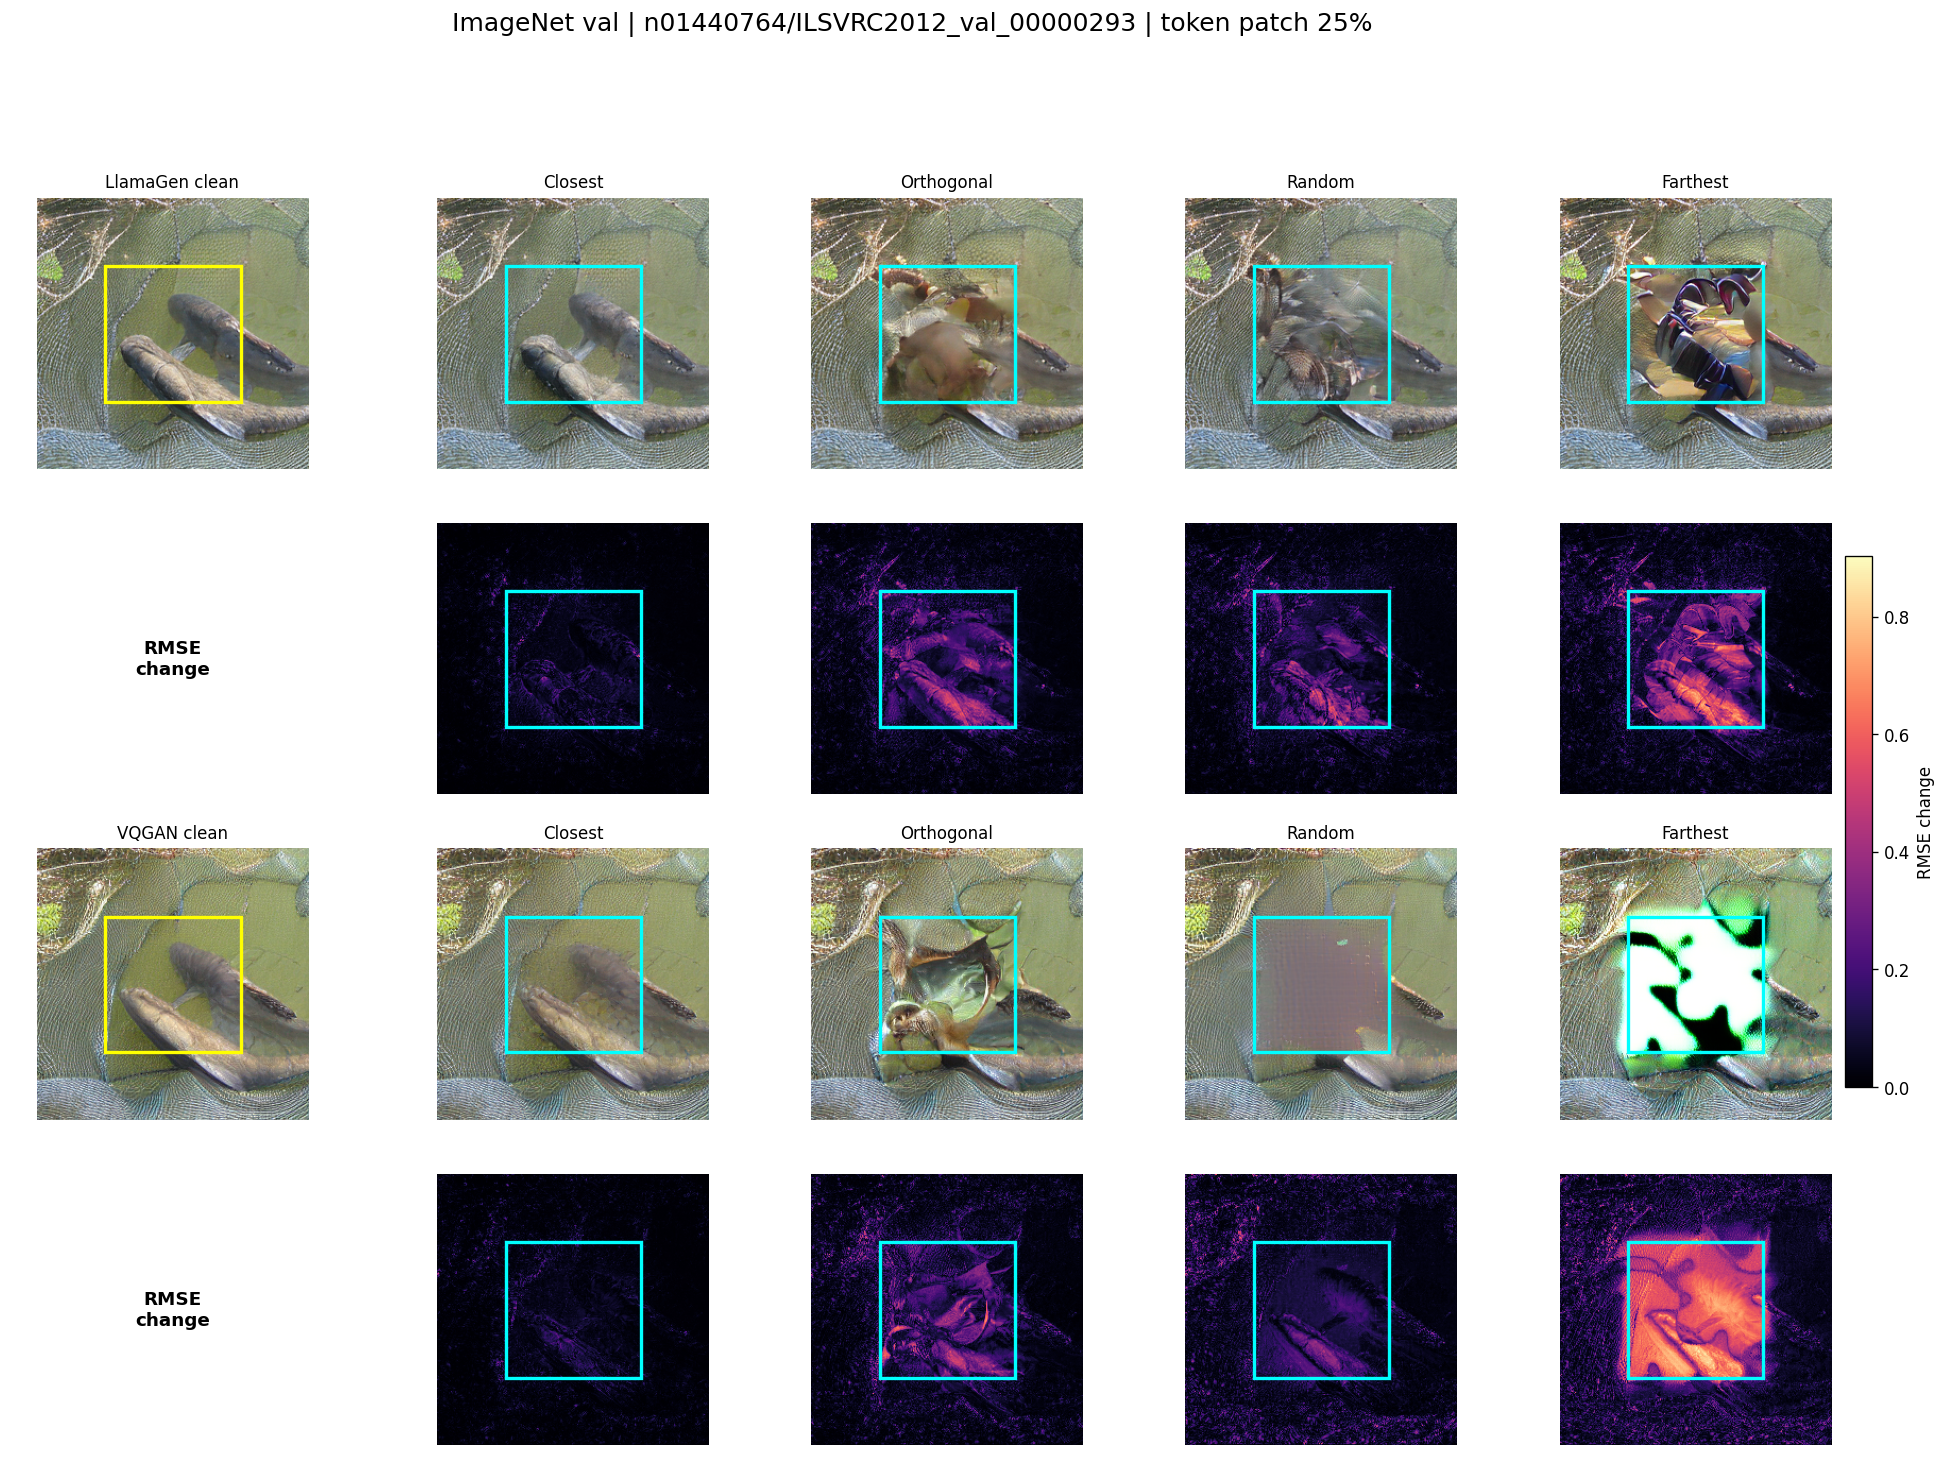

In [16]:
def select_shared_qualitative_id(dataset: str = "imagenet_val", fraction: str = "25") -> str:
    ids_by_model = []
    for model in MODEL_ORDER:
        sub = variants_df[
            (variants_df["dataset"] == dataset) &
            (variants_df["model"] == model) &
            (variants_df["fraction_label"].astype(str) == fraction)
        ]
        ids_by_model.append(set(sub["image_id"].astype(str)))
    shared = sorted(set.intersection(*ids_by_model))
    return shared[0]


def resolve_variant_image_path(path_value, dataset, model):
    path = Path(path_value)
    if path.exists():
        return path
    parts = path.parts
    if "images" not in parts:
        return path
    rel = Path(*parts[parts.index("images"):])
    return raw_dir(dataset, model) / rel


def make_qualitative_panel(dataset="imagenet_val", fraction="25", image_id=None):
    if image_id is None:
        image_id = select_shared_qualitative_id(dataset, fraction)

    fig, axes = plt.subplots(4, 1 + len(MODE_ORDER), figsize=(4.0 * (1 + len(MODE_ORDER)), 13.5))
    fig.suptitle(f"{DATASET_LABELS[dataset]} | {image_id} | token patch {fraction}%", fontsize=15, y=0.995)

    vmax = 0.0
    panel_data = {}
    for model in MODEL_ORDER:
        sub = variants_df[
            (variants_df["dataset"] == dataset) &
            (variants_df["model"] == model) &
            (variants_df["image_id"].astype(str) == image_id) &
            (variants_df["fraction_label"].astype(str) == fraction)
        ]
        clean_path = resolve_variant_image_path(sub["clean_path"].iloc[0], dataset, model)
        clean = load_img_float01(clean_path)
        panel_data[model] = {"clean": clean, "rows": {}}
        for mode in MODE_ORDER:
            one = sub[sub["mode"].astype(str) == mode].iloc[0]
            edit_path = resolve_variant_image_path(one["edit_path"], dataset, model)
            edit = load_img_float01(edit_path)
            heat = delta_map_rmse(clean, edit)
            bbox = [one["x0"], one["y0"], one["x1"], one["y1"]]
            panel_data[model]["rows"][mode] = {"edit": edit, "heat": heat, "bbox": bbox}
            vmax = max(vmax, float(heat.max()))

    for row_pair, model in enumerate(MODEL_ORDER):
        image_row = row_pair * 2
        heat_row = image_row + 1
        clean = panel_data[model]["clean"]
        first_bbox = panel_data[model]["rows"][MODE_ORDER[0]]["bbox"]
        draw_image(axes[image_row, 0], clean, f"{MODEL_LABELS[model]} clean", bbox_px=first_bbox, bbox_color="yellow")
        axes[heat_row, 0].axis("off")
        axes[heat_row, 0].text(0.5, 0.5, "RMSE\nchange", ha="center", va="center", fontsize=11, fontweight="bold")
        for col, mode in enumerate(MODE_ORDER, start=1):
            item = panel_data[model]["rows"][mode]
            draw_image(axes[image_row, col], item["edit"], MODE_LABELS[mode], bbox_px=item["bbox"])
            im = draw_heatmap(axes[heat_row, col], item["heat"], "", bbox_px=item["bbox"], vmax=vmax)

    fig.colorbar(im, ax=axes[:, 1:].ravel().tolist(), fraction=0.018, pad=0.01, label="RMSE change")
    return fig


qual_image_id = select_shared_qualitative_id("imagenet_val", "25")
print("selected qualitative image:", qual_image_id)
fig = make_qualitative_panel("imagenet_val", "25", qual_image_id)
save_figure(fig, "ch07_fig_token_edit_qualitative_imagenet_val_patch25.png")
plt.show()

for model in MODEL_ORDER:
    src = raw_dir("imagenet_val", model) / "images" / qual_image_id
    dst = QUAL_DIR / model / qual_image_id
    dst.parent.mkdir(parents=True, exist_ok=True)
    if dst.exists():
        shutil.rmtree(dst)
    shutil.copytree(src, dst)


## 7. Metric Formalization

Let $z_0 \in \{1,\ldots,K\}^{h \times w}$ be the clean token grid and let $B_{\mathrm{tok}}$ be a contiguous token patch. For an edit mode $m$, construct an edited grid $z^{(m)}$ such that

$$
z^{(m)}_{i,j} = z_{0,i,j}\quad \mathrm{for}\ (i,j) \notin B_{\mathrm{tok}},
$$

and positions inside $B_{\mathrm{tok}}$ are replaced according to the mode: closest neighbor, approximately orthogonal code, uniformly random code, or farthest code. The clean and edited reconstructions are

$$
x_{\mathrm{clean}} = D(z_0), \qquad x_{\mathrm{edit}}^{(m)} = D(z^{(m)}).
$$

For decoder locality, define a per-pixel RMSE change map

$$
\Delta^{(m)}(u,v) = \sqrt{\frac{1}{3}\sum_{c=1}^{3}\left(x_{\mathrm{edit}}^{(m)}(u,v,c)-x_{\mathrm{clean}}(u,v,c)\right)^2}.
$$

Let $B_{\mathrm{px}}$ be the pixel-space region corresponding to the edited token patch. The inside and outside decoder responses are

$$
\Delta_{\mathrm{in}}^{(m)} = \frac{1}{|B_{\mathrm{px}}|}\sum_{(u,v)\in B_{\mathrm{px}}}\Delta^{(m)}(u,v), \qquad
\Delta_{\mathrm{out}}^{(m)} = \frac{1}{|\overline{B}_{\mathrm{px}}|}\sum_{(u,v)\notin B_{\mathrm{px}}}\Delta^{(m)}(u,v).
$$

The leakage ratio reports how much decoder response escapes the edited region:

$$
\rho^{(m)} = \frac{\Delta_{\mathrm{out}}^{(m)}}{\Delta_{\mathrm{in}}^{(m)} + \epsilon}.
$$

Fidelity is measured with full-image and patch-restricted PSNR, SSIM, and LPIPS. The full-image metrics describe perceptual damage to the whole reconstruction, while the inside/outside and leakage metrics separate local edit strength from non-local spread.


## 8. Fidelity Summary

This section aggregates full-image and patch-level PSNR, SSIM, and LPIPS for each dataset, model, patch fraction, and edit mode.

Planned outputs:

- `ch07_table_fidelity_summary.csv`
- `ch07_fig_patch_lpips_imagenet_val.png`
- `ch07_fig_fidelity_patch25_imagenet_val.png`


saved: /exp/vq-explore/notebooks/chapter7_outputs/data/ch07_table_fidelity_summary.csv


,dataset,fraction_label,model,mode,n,psnr_full_mean,psnr_full_std,psnr_patch_mean,psnr_patch_std,ssim_full_mean,ssim_full_std,ssim_patch_mean,ssim_patch_std,lpips_full_mean,lpips_full_std,lpips_patch_mean,lpips_patch_std
0,imagenet_sketch,10,llamagen,closest,50889,27.827122,6.207131,NaN,NaN,0.953068,0.021452,0.666074,0.151025,0.022564,0.009624,0.100056,0.043702
1,imagenet_sketch,10,llamagen,orthogonal,50889,19.339519,2.753057,10.438949,2.769695,0.857872,0.032659,0.144259,0.108535,0.114979,0.018877,0.535745,0.087422
2,imagenet_sketch,10,llamagen,random_uniform,50889,19.279347,2.496248,10.359333,2.526298,0.859313,0.032070,0.152003,0.106652,0.114313,0.019096,0.531219,0.084907
3,imagenet_sketch,10,llamagen,farthest,50889,15.747844,1.818192,6.526996,1.935491,0.830989,0.031802,0.037527,0.048754,0.149779,0.027768,0.650534,0.104578
4,imagenet_sketch,10,vqgan,closest,50889,25.516161,4.668377,NaN,NaN,0.936057,0.027192,0.609788,0.159533,0.032287,0.012967,0.130883,0.055985
5,imagenet_sketch,10,vqgan,orthogonal,50889,17.608035,2.174866,9.168418,2.053046,0.819915,0.046210,0.094877,0.076596,0.139894,0.023881,0.556799,0.088312
6,imagenet_sketch,10,vqgan,random_uniform,50889,19.126257,2.431493,11.086626,2.258573,0.831750,0.048926,0.182821,0.123523,0.139501,0.023469,0.635044,0.090082
7,imagenet_sketch,10,vqgan,farthest,50889,12.297533,1.316482,3.247705,1.476113,0.777132,0.051209,0.013623,0.035545,0.206742,0.034648,0.735104,0.086520
8,imagenet_sketch,25,llamagen,closest,50889,24.241635,5.917272,NaN,NaN,0.899940,0.044839,0.677138,0.138165,0.050146,0.018769,0.121447,0.045215
9,imagenet_sketch,25,llamagen,orthogonal,50889,14.918173,1.978491,9.489043,1.973070,0.705460,0.056089,0.144720,0.082308,0.261780,0.029310,0.623063,0.065303


saved: /exp/vq-explore/notebooks/chapter7_outputs/figures/ch07_fig_patch_lpips_imagenet_val.png


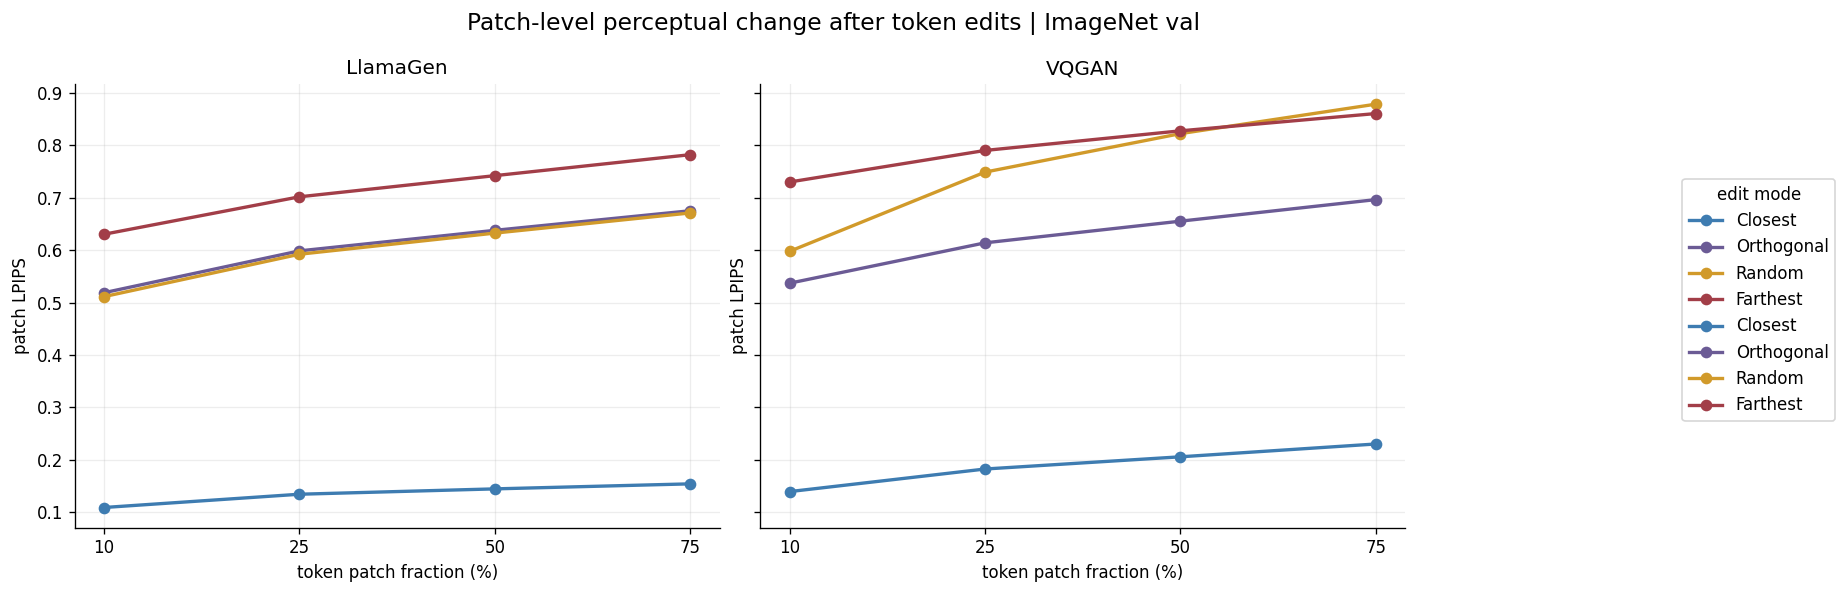

saved: /exp/vq-explore/notebooks/chapter7_outputs/figures/ch07_fig_fidelity_patch25_imagenet_val.png


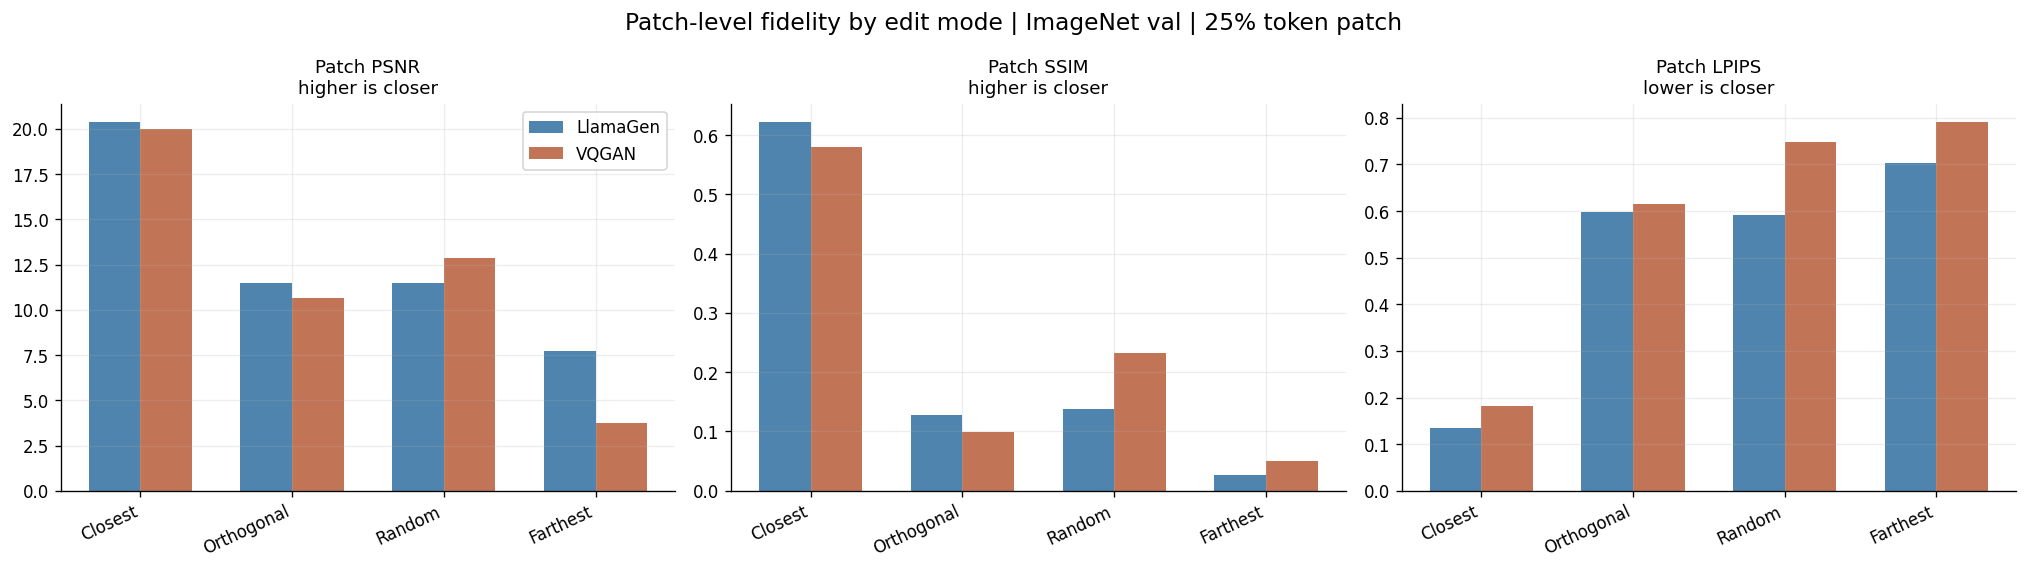

In [17]:
summary_fidelity = (
    merged_df
    .groupby(["dataset", "fraction_label", "model", "mode"], as_index=False, observed=True)
    .agg(
        n=("image_id", "count"),
        psnr_full_mean=("psnr_full", "mean"),
        psnr_full_std=("psnr_full", "std"),
        psnr_patch_mean=("psnr_patch", "mean"),
        psnr_patch_std=("psnr_patch", "std"),
        ssim_full_mean=("ssim_full", "mean"),
        ssim_full_std=("ssim_full", "std"),
        ssim_patch_mean=("ssim_patch", "mean"),
        ssim_patch_std=("ssim_patch", "std"),
        lpips_full_mean=("lpips_full", "mean"),
        lpips_full_std=("lpips_full", "std"),
        lpips_patch_mean=("lpips_patch", "mean"),
        lpips_patch_std=("lpips_patch", "std"),
    )
    .sort_values(["dataset", "fraction_label", "model", "mode"])
    .reset_index(drop=True)
)
save_table(summary_fidelity, "ch07_table_fidelity_summary.csv")
display(summary_fidelity.head(16))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = summary_fidelity[(summary_fidelity["dataset"] == "imagenet_val") & (summary_fidelity["model"] == model)]
    for mode in MODE_ORDER:
        one = sub[sub["mode"].astype(str) == mode].sort_values("fraction_label")
        ax.plot(
            one["fraction_label"].astype(str),
            one["lpips_patch_mean"],
            marker="o",
            linewidth=2,
            color=MODE_COLORS[mode],
            label=MODE_LABELS[mode],
        )
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("token patch fraction (%)")
    ax.set_ylabel("patch LPIPS")
fig.suptitle("Patch-level perceptual change after token edits | ImageNet val", fontsize=14)
fig.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="edit mode")
fig.tight_layout()
fig.subplots_adjust(right=0.84)
save_figure(fig, "ch07_fig_patch_lpips_imagenet_val.png")
plt.show()

fraction = "25"
metrics = [
    ("psnr_patch_mean", "Patch PSNR", "higher is closer"),
    ("ssim_patch_mean", "Patch SSIM", "higher is closer"),
    ("lpips_patch_mean", "Patch LPIPS", "lower is closer"),
]
fig, axes = plt.subplots(1, 3, figsize=(17, 4.8))
x = np.arange(len(MODE_ORDER))
width = 0.34
for ax, (metric, title, subtitle) in zip(axes, metrics):
    for offset, model in [(-width / 2, "llamagen"), (width / 2, "vqgan")]:
        sub = summary_fidelity[
            (summary_fidelity["dataset"] == "imagenet_val") &
            (summary_fidelity["fraction_label"].astype(str) == fraction) &
            (summary_fidelity["model"] == model)
        ]
        vals = [float(sub[sub["mode"].astype(str) == mode][metric].iloc[0]) for mode in MODE_ORDER]
        ax.bar(x + offset, vals, width=width, label=MODEL_LABELS[model], color=MODEL_COLORS[model], alpha=0.85)
    ax.set_title(f"{title}\n{subtitle}", fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels([MODE_LABELS[m] for m in MODE_ORDER], rotation=25, ha="right")
fig.suptitle("Patch-level fidelity by edit mode | ImageNet val | 25% token patch", fontsize=14)
axes[0].legend()
fig.tight_layout()
save_figure(fig, "ch07_fig_fidelity_patch25_imagenet_val.png")
plt.show()


## 9. Decoder Locality Summary

This section aggregates the decoder response inside and outside the edited pixel region. The leakage ratio normalizes outside change by inside change; outside p99 and p999 capture high-end tails outside the target region.

Planned outputs:

- `ch07_table_locality_summary.csv`
- `ch07_fig_decoder_locality_imagenet_val.png`
- `ch07_fig_leakage_ratio_imagenet_val.png`


saved: /exp/vq-explore/notebooks/chapter7_outputs/data/ch07_table_locality_summary.csv


,dataset,fraction_label,model,mode,n,inside_change_mean,inside_change_std,outside_change_mean,outside_change_std,leakage_ratio_mean,leakage_ratio_std,leakage_ratio_median,outside_p99_mean,outside_p99_std,outside_p999_mean,outside_p999_std
0,imagenet_sketch,10,llamagen,closest,50889,0.074334,0.038501,0.007296,0.004000,9.602612,856.696983,0.099809,0.103903,0.051388,0.275375,0.112226
1,imagenet_sketch,10,llamagen,orthogonal,50889,0.254088,0.072361,0.022460,0.008709,0.091057,0.034448,0.086935,0.268222,0.093930,0.530472,0.154251
2,imagenet_sketch,10,llamagen,random_uniform,50889,0.253269,0.072429,0.022306,0.008680,0.090831,0.033768,0.086965,0.266768,0.094471,0.531937,0.155347
3,imagenet_sketch,10,llamagen,farthest,50889,0.419391,0.101643,0.029117,0.010111,0.072058,0.027632,0.068201,0.349417,0.105573,0.643865,0.147736
4,imagenet_sketch,10,vqgan,closest,50889,0.087479,0.045841,0.011374,0.006425,1.644549,334.865010,0.132846,0.171022,0.086296,0.414961,0.169417
5,imagenet_sketch,10,vqgan,orthogonal,50889,0.282878,0.066682,0.027921,0.012923,0.100304,0.044000,0.093846,0.391909,0.142493,0.677575,0.173917
6,imagenet_sketch,10,vqgan,random_uniform,50889,0.252127,0.063766,0.028243,0.012933,0.115776,0.053823,0.105594,0.349590,0.132835,0.601024,0.182705
7,imagenet_sketch,10,vqgan,farthest,50889,0.606124,0.126358,0.041368,0.016875,0.071382,0.034017,0.065385,0.587709,0.164879,0.908835,0.103178
8,imagenet_sketch,25,llamagen,closest,50889,0.071258,0.034100,0.010095,0.006108,5.317268,1122.466835,0.141519,0.129888,0.065768,0.307894,0.123408
9,imagenet_sketch,25,llamagen,orthogonal,50889,0.287096,0.066514,0.036407,0.014324,0.128317,0.047753,0.123927,0.329408,0.114186,0.570914,0.153183


saved: /exp/vq-explore/notebooks/chapter7_outputs/figures/ch07_fig_decoder_locality_imagenet_val.png


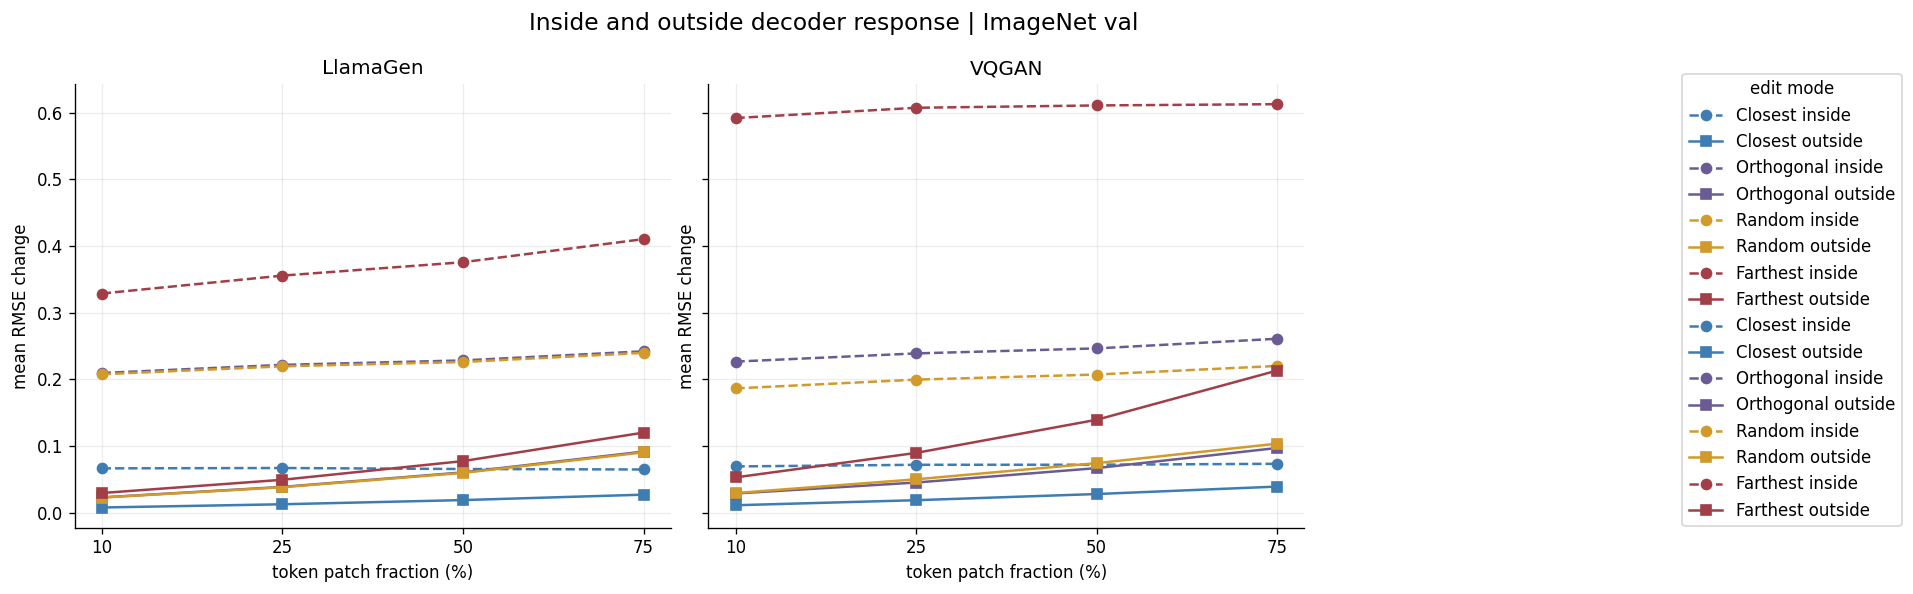

saved: /exp/vq-explore/notebooks/chapter7_outputs/figures/ch07_fig_leakage_ratio_imagenet_val.png


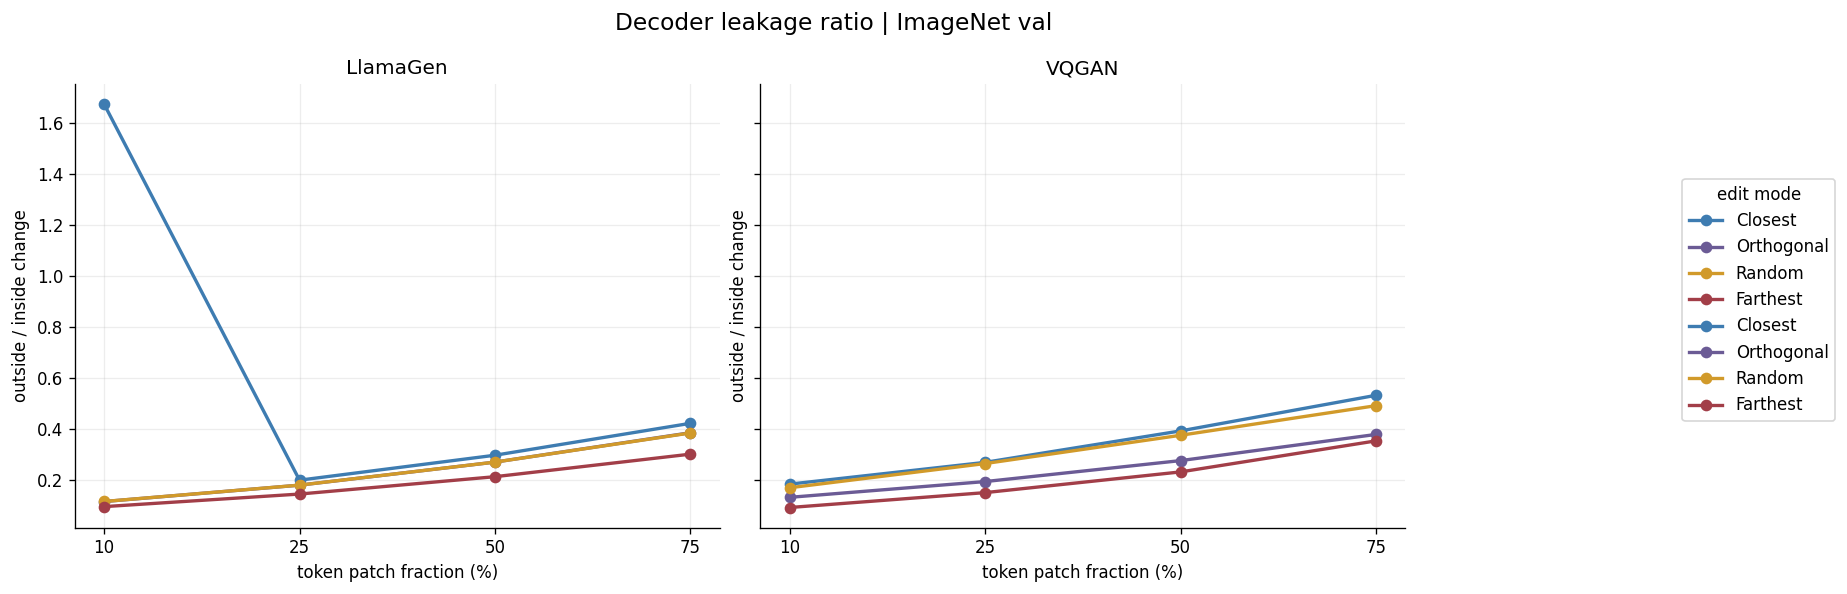

In [18]:
summary_locality = (
    pixel_df
    .groupby(["dataset", "fraction_label", "model", "mode"], as_index=False, observed=True)
    .agg(
        n=("image_id", "count"),
        inside_change_mean=("inside_change", "mean"),
        inside_change_std=("inside_change", "std"),
        outside_change_mean=("outside_change", "mean"),
        outside_change_std=("outside_change", "std"),
        leakage_ratio_mean=("leakage_ratio_safe", "mean"),
        leakage_ratio_std=("leakage_ratio_safe", "std"),
        leakage_ratio_median=("leakage_ratio_safe", "median"),
        outside_p99_mean=("outside_p99", "mean"),
        outside_p99_std=("outside_p99", "std"),
        outside_p999_mean=("outside_p999", "mean"),
        outside_p999_std=("outside_p999", "std"),
    )
    .sort_values(["dataset", "fraction_label", "model", "mode"])
    .reset_index(drop=True)
)
save_table(summary_locality, "ch07_table_locality_summary.csv")
display(summary_locality.head(16))

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = summary_locality[(summary_locality["dataset"] == "imagenet_val") & (summary_locality["model"] == model)]
    for mode in MODE_ORDER:
        one = sub[sub["mode"].astype(str) == mode].sort_values("fraction_label")
        ax.plot(one["fraction_label"].astype(str), one["inside_change_mean"], marker="o", linestyle="--", color=MODE_COLORS[mode], label=f"{MODE_LABELS[mode]} inside")
        ax.plot(one["fraction_label"].astype(str), one["outside_change_mean"], marker="s", linestyle="-", color=MODE_COLORS[mode], label=f"{MODE_LABELS[mode]} outside")
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("token patch fraction (%)")
    ax.set_ylabel("mean RMSE change")
fig.suptitle("Inside and outside decoder response | ImageNet val", fontsize=14)
fig.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="edit mode")
fig.tight_layout()
fig.subplots_adjust(right=0.78)
save_figure(fig, "ch07_fig_decoder_locality_imagenet_val.png")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = summary_locality[(summary_locality["dataset"] == "imagenet_val") & (summary_locality["model"] == model)]
    for mode in MODE_ORDER:
        one = sub[sub["mode"].astype(str) == mode].sort_values("fraction_label")
        ax.plot(one["fraction_label"].astype(str), one["leakage_ratio_mean"], marker="o", linewidth=2, color=MODE_COLORS[mode], label=MODE_LABELS[mode])
    ax.set_title(MODEL_LABELS[model])
    ax.set_xlabel("token patch fraction (%)")
    ax.set_ylabel("outside / inside change")
fig.suptitle("Decoder leakage ratio | ImageNet val", fontsize=14)
fig.legend(loc="center left", bbox_to_anchor=(1.0, 0.5), title="edit mode")
fig.tight_layout()
fig.subplots_adjust(right=0.84)
save_figure(fig, "ch07_fig_leakage_ratio_imagenet_val.png")
plt.show()


## 10. Joint Chapter Table

Combine the most important fidelity and locality quantities into one compact table. This is the table most likely to feed directly into Chapter 7.

Planned output:

- `ch07_table_joint_decoder_locality_summary.csv`


In [19]:
joint_summary = summary_locality.merge(
    summary_fidelity[
        [
            "dataset", "fraction_label", "model", "mode",
            "psnr_patch_mean", "ssim_patch_mean", "lpips_patch_mean",
            "psnr_full_mean", "ssim_full_mean", "lpips_full_mean",
        ]
    ],
    on=["dataset", "fraction_label", "model", "mode"],
    how="inner",
)

joint_summary = joint_summary[
    [
        "dataset", "fraction_label", "model", "mode", "n",
        "inside_change_mean", "outside_change_mean", "leakage_ratio_mean",
        "outside_p99_mean", "outside_p999_mean",
        "psnr_patch_mean", "ssim_patch_mean", "lpips_patch_mean",
        "psnr_full_mean", "ssim_full_mean", "lpips_full_mean",
    ]
]
save_table(joint_summary, "ch07_table_joint_decoder_locality_summary.csv")
display(joint_summary[(joint_summary["dataset"] == "imagenet_val") & (joint_summary["fraction_label"].astype(str) == "25")])


saved: /exp/vq-explore/notebooks/chapter7_outputs/data/ch07_table_joint_decoder_locality_summary.csv


,dataset,fraction_label,model,mode,n,inside_change_mean,outside_change_mean,leakage_ratio_mean,outside_p99_mean,outside_p999_mean,psnr_patch_mean,ssim_patch_mean,lpips_patch_mean,psnr_full_mean,ssim_full_mean,lpips_full_mean
40,imagenet_val,25,llamagen,closest,50000,0.067282,0.012932,0.199081,0.104957,0.233384,20.363229,0.621705,0.134201,25.529309,0.873986,0.056944
41,imagenet_val,25,llamagen,orthogonal,50000,0.221903,0.038929,0.179502,0.251334,0.441350,11.452630,0.128549,0.598736,16.736785,0.655867,0.261433
42,imagenet_val,25,llamagen,random_uniform,50000,0.219676,0.038469,0.179534,0.249717,0.443022,11.480835,0.138274,0.592318,16.770880,0.660483,0.258411
43,imagenet_val,25,llamagen,farthest,50000,0.355678,0.049631,0.144555,0.327661,0.553853,7.737221,0.027365,0.701948,13.218934,0.600313,0.323833
44,imagenet_val,25,vqgan,closest,50000,0.072099,0.019026,0.269018,0.147647,0.310775,20.001638,0.579106,0.182335,24.602735,0.841568,0.080024
45,imagenet_val,25,vqgan,orthogonal,50000,0.239041,0.045511,0.193550,0.317048,0.537268,10.664759,0.098362,0.614092,15.771223,0.603638,0.294944
46,imagenet_val,25,vqgan,random_uniform,50000,0.199764,0.050322,0.264263,0.302130,0.487441,12.834046,0.232335,0.749104,17.379562,0.609086,0.321423
47,imagenet_val,25,vqgan,farthest,50000,0.607231,0.089931,0.150152,0.672883,0.854189,3.735027,0.049567,0.790446,9.028046,0.474283,0.439934


## 11. Dataset Shift Comparison

The v2 notebook compares ImageNet validation and ImageNetV2. Here the same comparison is kept compact: raw mean difference and standardized difference using pooled standard deviation.

Planned outputs:

- `ch07_table_dataset_shift_imagenetv2_minus_val.csv`
- `ch07_fig_dataset_shift_lpips_patch.png`


saved: /exp/vq-explore/notebooks/chapter7_outputs/data/ch07_table_dataset_shift_imagenetv2_minus_val.csv


,metric,model,fraction_label,mode,mean_val,mean_v2,delta,pooled_std,delta_sigma
0,psnr_patch,llamagen,10,closest,NaN,20.720434,NaN,NaN,NaN
1,psnr_patch,llamagen,10,orthogonal,11.946000,11.924831,-0.021169,2.216964,-0.009549
2,psnr_patch,llamagen,10,random_uniform,11.974101,11.929860,-0.044241,2.316846,-0.019095
3,psnr_patch,llamagen,10,farthest,8.417614,8.290667,-0.126948,2.133528,-0.059501
4,psnr_patch,llamagen,25,closest,20.363229,20.435528,0.072299,3.000493,0.024096
5,psnr_patch,llamagen,25,orthogonal,11.452630,11.430813,-0.021817,1.758577,-0.012406
6,psnr_patch,llamagen,25,random_uniform,11.480835,11.454522,-0.026313,1.826982,-0.014403
7,psnr_patch,llamagen,25,farthest,7.737221,7.590564,-0.146657,1.807237,-0.081150
8,psnr_patch,llamagen,50,closest,20.440267,20.544368,0.104101,2.733598,0.038082
9,psnr_patch,llamagen,50,orthogonal,11.240862,11.218168,-0.022694,1.574099,-0.014417


saved: /exp/vq-explore/notebooks/chapter7_outputs/figures/ch07_fig_dataset_shift_lpips_patch.png


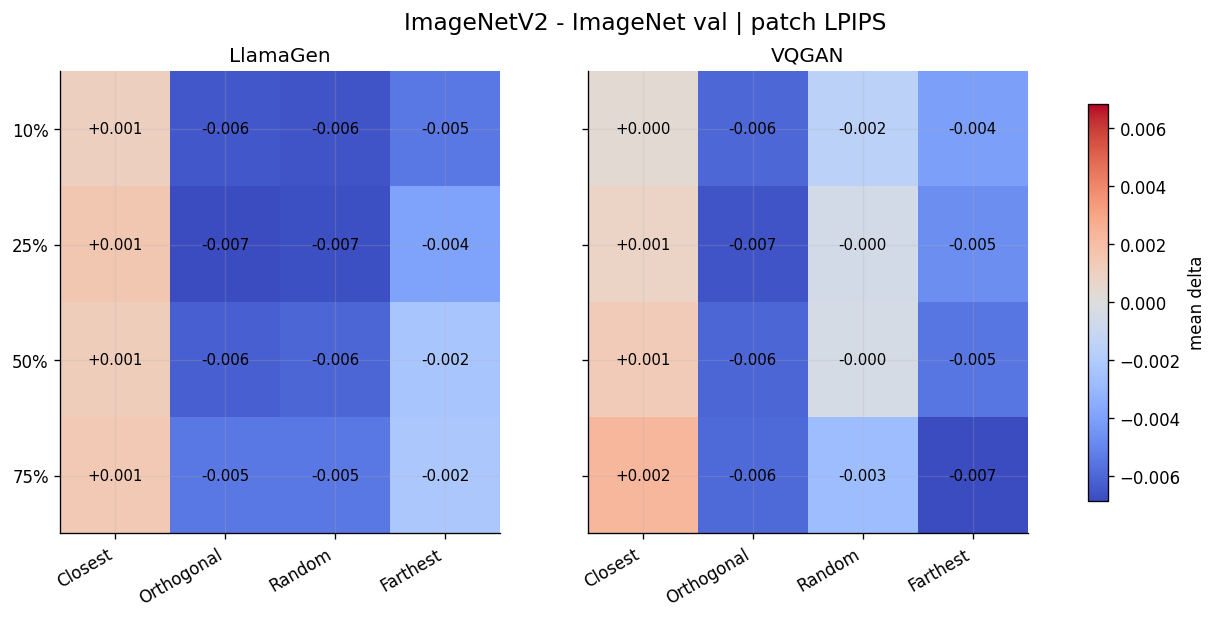

In [20]:
def dataset_shift_table(metric_mean: str, metric_std: str, source: pd.DataFrame, metric_label: str) -> pd.DataFrame:
    rows = []
    for model in MODEL_ORDER:
        for fraction in FRACTION_ORDER:
            for mode in MODE_ORDER:
                val = source[
                    (source["dataset"] == "imagenet_val") &
                    (source["model"] == model) &
                    (source["fraction_label"].astype(str) == fraction) &
                    (source["mode"].astype(str) == mode)
                ].iloc[0]
                v2 = source[
                    (source["dataset"] == "imagenetv2") &
                    (source["model"] == model) &
                    (source["fraction_label"].astype(str) == fraction) &
                    (source["mode"].astype(str) == mode)
                ].iloc[0]
                pooled = math.sqrt((float(val[metric_std]) ** 2 + float(v2[metric_std]) ** 2) / 2.0)
                delta = float(v2[metric_mean]) - float(val[metric_mean])
                rows.append({
                    "metric": metric_label,
                    "model": model,
                    "fraction_label": fraction,
                    "mode": mode,
                    "mean_val": float(val[metric_mean]),
                    "mean_v2": float(v2[metric_mean]),
                    "delta": delta,
                    "pooled_std": pooled,
                    "delta_sigma": delta / pooled if pooled > 0 else np.nan,
                })
    return pd.DataFrame(rows)

shift_tables = [
    dataset_shift_table("psnr_patch_mean", "psnr_patch_std", summary_fidelity, "psnr_patch"),
    dataset_shift_table("ssim_patch_mean", "ssim_patch_std", summary_fidelity, "ssim_patch"),
    dataset_shift_table("lpips_patch_mean", "lpips_patch_std", summary_fidelity, "lpips_patch"),
    dataset_shift_table("outside_change_mean", "outside_change_std", summary_locality, "outside_change"),
    dataset_shift_table("leakage_ratio_mean", "leakage_ratio_std", summary_locality, "leakage_ratio"),
]
dataset_shift_df = pd.concat(shift_tables, ignore_index=True)
save_table(dataset_shift_df, "ch07_table_dataset_shift_imagenetv2_minus_val.csv")
display(dataset_shift_df.head(16))

plot_metric = "lpips_patch"
plot_df = dataset_shift_df[dataset_shift_df["metric"] == plot_metric]
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, model in zip(axes, MODEL_ORDER):
    sub = plot_df[plot_df["model"] == model]
    heat = (
        sub.pivot(index="fraction_label", columns="mode", values="delta")
        .reindex(index=FRACTION_ORDER, columns=MODE_ORDER)
    )
    vmax = max(float(np.nanmax(np.abs(heat.to_numpy()))), 1e-8)
    im = ax.imshow(heat.to_numpy(dtype=float), cmap="coolwarm", vmin=-vmax, vmax=vmax, aspect="auto")
    ax.set_title(MODEL_LABELS[model])
    ax.set_xticks(range(len(MODE_ORDER)))
    ax.set_xticklabels([MODE_LABELS[m] for m in MODE_ORDER], rotation=30, ha="right")
    ax.set_yticks(range(len(FRACTION_ORDER)))
    ax.set_yticklabels([f"{f}%" for f in FRACTION_ORDER])
    for i in range(len(FRACTION_ORDER)):
        for j in range(len(MODE_ORDER)):
            value = heat.iloc[i, j]
            if np.isfinite(value):
                ax.text(j, i, f"{value:+.3f}", ha="center", va="center", fontsize=9)
fig.suptitle("ImageNetV2 - ImageNet val | patch LPIPS", fontsize=14)
fig.colorbar(im, ax=axes, shrink=0.86, label="mean delta")
save_figure(fig, "ch07_fig_dataset_shift_lpips_patch.png")
plt.show()


## 12. Chapter Notes

Write a compact markdown file with the headline values most likely to be used when drafting Chapter 7.

Planned output:

- `ch07_chapter_notes.md`


In [21]:
def fmt(value: float) -> str:
    return f"{value:.4f}"

lines = ["# Chapter 7 Notes", ""]
lines.append("## ImageNet val, 25% token patch")
subset = joint_summary[(joint_summary["dataset"] == "imagenet_val") & (joint_summary["fraction_label"].astype(str) == "25")]
for _, row in subset.sort_values(["model", "mode"]).iterrows():
    lines.append(
        f"- {MODEL_LABELS[row['model']]} {MODE_LABELS[row['mode']]}: "
        f"inside={fmt(row['inside_change_mean'])}, "
        f"outside={fmt(row['outside_change_mean'])}, "
        f"leakage={fmt(row['leakage_ratio_mean'])}, "
        f"patch LPIPS={fmt(row['lpips_patch_mean'])}, "
        f"patch PSNR={fmt(row['psnr_patch_mean'])}."
    )

lines.append("")
lines.append("## ImageNet val, 50% token patch")
subset = joint_summary[(joint_summary["dataset"] == "imagenet_val") & (joint_summary["fraction_label"].astype(str) == "50")]
for _, row in subset.sort_values(["model", "mode"]).iterrows():
    lines.append(
        f"- {MODEL_LABELS[row['model']]} {MODE_LABELS[row['mode']]}: "
        f"inside={fmt(row['inside_change_mean'])}, "
        f"outside={fmt(row['outside_change_mean'])}, "
        f"leakage={fmt(row['leakage_ratio_mean'])}, "
        f"patch LPIPS={fmt(row['lpips_patch_mean'])}."
    )

notes_path = DATA_DIR / "ch07_chapter_notes.md"
notes_path.write_text("\n".join(lines) + "\n")
print(notes_path.read_text())


# Chapter 7 Notes

## ImageNet val, 25% token patch
- LlamaGen Closest: inside=0.0673, outside=0.0129, leakage=0.1991, patch LPIPS=0.1342, patch PSNR=20.3632.
- LlamaGen Orthogonal: inside=0.2219, outside=0.0389, leakage=0.1795, patch LPIPS=0.5987, patch PSNR=11.4526.
- LlamaGen Random: inside=0.2197, outside=0.0385, leakage=0.1795, patch LPIPS=0.5923, patch PSNR=11.4808.
- LlamaGen Farthest: inside=0.3557, outside=0.0496, leakage=0.1446, patch LPIPS=0.7019, patch PSNR=7.7372.
- VQGAN Closest: inside=0.0721, outside=0.0190, leakage=0.2690, patch LPIPS=0.1823, patch PSNR=20.0016.
- VQGAN Orthogonal: inside=0.2390, outside=0.0455, leakage=0.1935, patch LPIPS=0.6141, patch PSNR=10.6648.
- VQGAN Random: inside=0.1998, outside=0.0503, leakage=0.2643, patch LPIPS=0.7491, patch PSNR=12.8340.
- VQGAN Farthest: inside=0.6072, outside=0.0899, leakage=0.1502, patch LPIPS=0.7904, patch PSNR=3.7350.

## ImageNet val, 50% token patch
- LlamaGen Closest: inside=0.0658, outside=0.0192, leakage=0.2969,